# 

In [1]:
import pandas as pd
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
train = pd.read_table('train.tsv')

# 'item_description' 결측치 : 'No description yet'과 동일한 값으로 처리
train['item_description'] = train['item_description'].fillna("No description yet")
# 'brand_name' 결측치 처리 :
# 1. 기존 브랜드명이 기재된 컬럼에는 1, 누락된 곳에는 0
# 2. 결측치처리 : 'No Brand'
train["has_brand"] = train["brand_name"].notna().astype(int)
train["brand_name"] = train["brand_name"].fillna("No Brand")
# 'category_name' 결측치 처리 : 'No Category/No category/No category' - 기존 카테고리 분류 형식과 동일하게
train["category_name"] = train["category_name"].fillna("No category/No category/No category")
# 처리 후 전체 결측치 현황 한눈에 보기
print("=== 결측치 처리 후 데이터 결측치 현황 ===")
print(train.isna().sum())
train[['cat_1', 'cat_2', 'cat_3']] = train['category_name'].str.split('/', n=2, expand=True)
print(train['cat_1'].value_counts().head(10))  # 상위 카테고리 확인

=== 결측치 처리 후 데이터 결측치 현황 ===
train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
has_brand            0
dtype: int64
cat_1
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Name: count, dtype: int64


In [124]:
# 3.  (최최종으로 가시죠 최수종)

#사실상 주 고객층이 70프로 정도가 여성이다라는 걸 알 수 있음

#여성을 타겟층으로 한 카테고리 분석 - 여성들이 선호하는 피처들 등등 분석해서 여성 타겟 마케팅 전략 제시 - 단어의 빈도수로만 보는거 같은데

#이거 팔릴까..? 하는 생각들을 해소해주는 소비자의 감정을 헤아려주는 착한 모델

#그렇게 되었을때 여성들이 쓰는 제품,남성들이 쓰는 제품의 차이 선호도의 분석이 어느 정도 가능

#저는 2번과 3번이 크게 다르다고 느끼지 않아요

#미니멈을 잡는다면 여성에 대한 고객층을 대상으로 얼마나 더 올라왔을까. 그건 eda겠죠 그러고나서 여유가 있으면 클러스터링도 가능!

#이 상품이 많다? -> 수요가 많겠구나! 라는생각. 

#2번과 3번이 저는 진짜 똑같아 보여요! 가장큰 차이점은 가격 모델링을 할필요가 없다 이거죠 -> 이건 매우 큰 장점 인정?

#클러스터링 고도화 재밌어보이긴 해

#단순 빈도수가 많다? -> 수요가 많다고는 못하잖아요 -> 크림만봐도 되는구나 이게 있네

#자 이제 모든 프로세스가 명확해! 뜯어보자 


In [3]:
cat1_proportions = train['cat_1'].value_counts(normalize=True)
print(cat1_proportions)

train[(train['cat_3']=='Women')&(train['cat_1']=='Beauty')] 


cat_1
Women                     0.448141
Beauty                    0.140184
Kids                      0.115808
Electronics               0.082757
Men                       0.063189
Home                      0.045780
Vintage & Collectibles    0.031385
Other                     0.030590
Handmade                  0.020804
Sports & Outdoors         0.017094
No category               0.004268
Name: proportion, dtype: float64


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand,cat_1,cat_2,cat_3
11,11,New vs pi k body mists,1,Beauty/Fragrance/Women,Victoria's Secret,34.0,0,(5) new vs pink body mists (2.5 oz each) Fresh...,1,Beauty,Fragrance,Women
113,113,Marc Jacobs Honey,2,Beauty/Fragrance/Women,MARC JACOBS,10.0,0,Roller ball full size unused with no box Fun s...,1,Beauty,Fragrance,Women
118,118,Pink body mist,3,Beauty/Fragrance/Women,Victoria's Secret,16.0,1,Bombshell & Eau So Sexy Bombshell was used a b...,1,Beauty,Fragrance,Women
166,166,Prada Candy Eau De Parfum,1,Beauty/Fragrance/Women,Sephora,12.0,1,This is my price. No lower prices. Lowballers ...,1,Beauty,Fragrance,Women
167,167,My Pure by Karen Low perfume,1,Beauty/Fragrance/Women,No Brand,7.0,0,Never been used - I will ship with the perfume...,0,Beauty,Fragrance,Women
...,...,...,...,...,...,...,...,...,...,...,...,...
1482411,1482411,Victoria's Secret Dark Angel Perfume,2,Beauty/Fragrance/Women,Victoria's Secret,27.0,0,Opened but never used. 1.7 oz.,1,Beauty,Fragrance,Women
1482446,1482446,Victoria Secrets perfume bundle,2,Beauty/Fragrance/Women,Victoria's Secret,10.0,1,Victoria secrets bundle was rarely used. Bath ...,1,Beauty,Fragrance,Women
1482476,1482476,Versace Yellow Diamond Mini,1,Beauty/Fragrance/Women,Sephora,8.0,1,This is a 0.17oz mini splash on perfume. No bo...,1,Beauty,Fragrance,Women
1482489,1482489,B&BW Lemongrass Sage body spray,2,Beauty/Fragrance/Women,Bath & Body Works,13.0,1,Lemongrass & Sage body spray smells amazing! 9...,1,Beauty,Fragrance,Women


In [4]:
train_filtered = train[(train['cat_1'] == 'Beauty') | (train['cat_1'] == 'Women')]
train_filtered #87만개

train_filtered['price_log'] = np.log1p(train_filtered['price'])


/var/folders/3m/2p4scd0107qfx4clslwxs3r80000gn/T/ipykernel_28316/2487554057.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_filtered['price_log'] = np.log1p(train_filtered['price'])


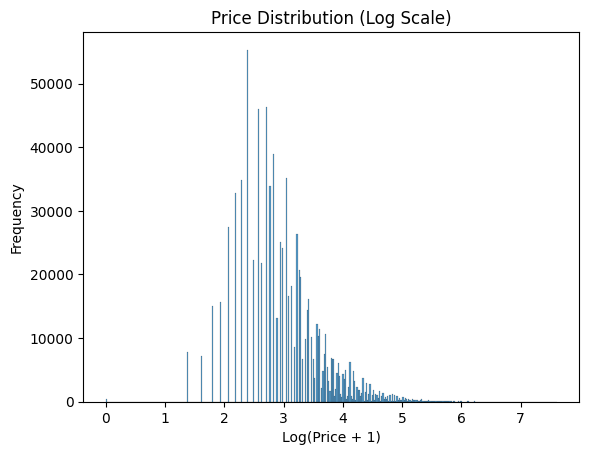

In [5]:
sns.histplot(train_filtered['price_log'])
plt.title('Price Distribution (Log Scale)')
plt.xlabel('Log(Price + 1)')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='item_condition_id', ylabel='price_log'>

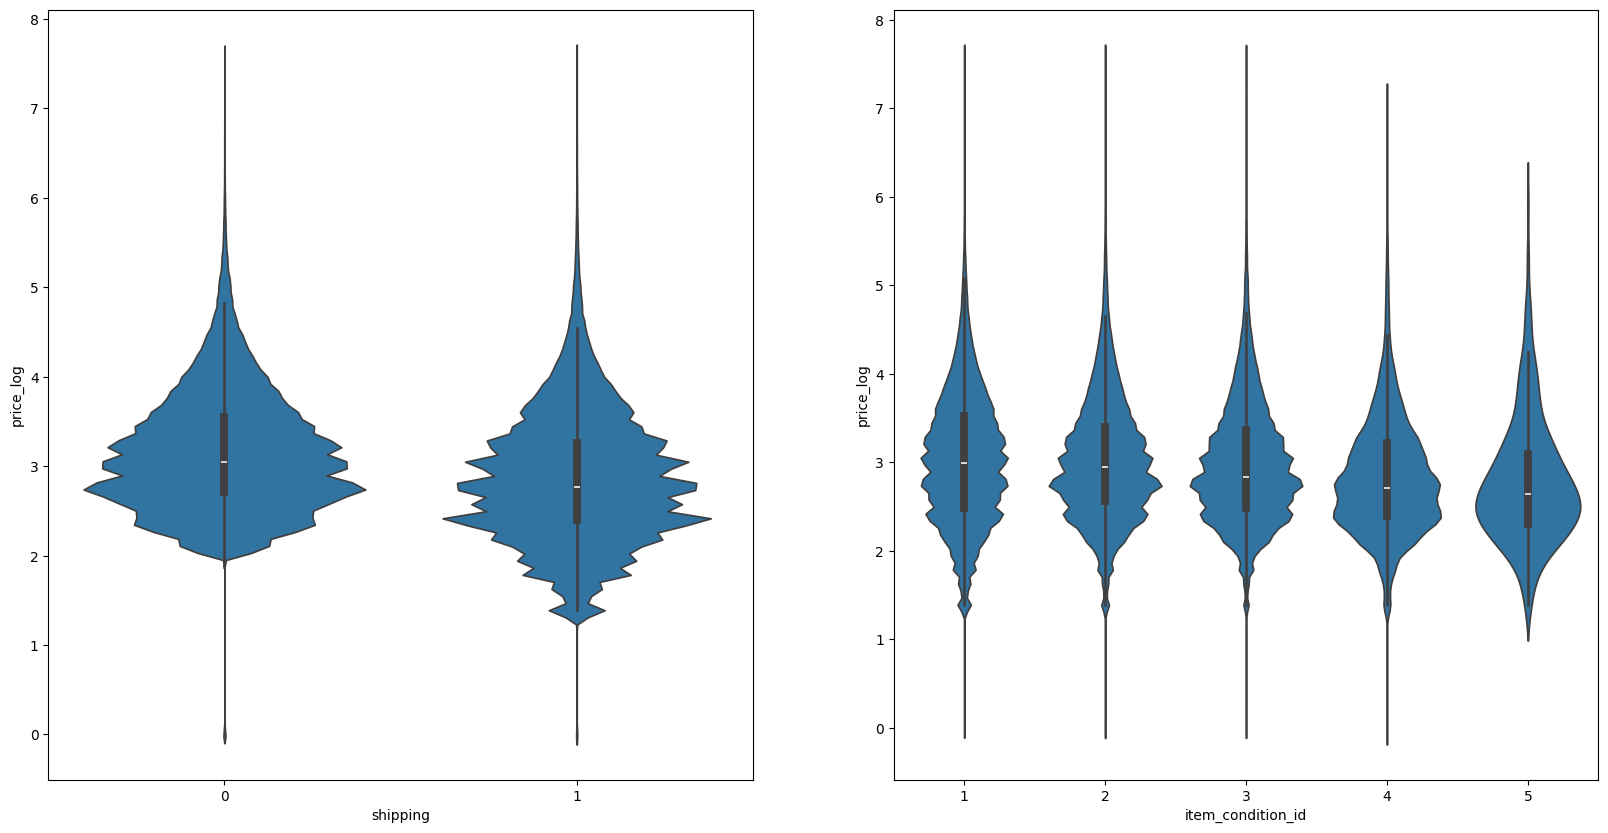

In [6]:
fig , ax = plt.subplots(1,2,figsize=(20,10))
sns.violinplot(data=train_filtered,x='shipping',y='price_log',ax=ax[0])
sns.violinplot(data=train_filtered,x='item_condition_id',y='price_log',ax=ax[1])


In [7]:
train_filtered.groupby('cat_1')['price_log']
train_filtered.groupby('cat_2')['price_log'].head()

2       2.397895
4       3.806662
5       4.094345
6       4.174387
10      2.197225
          ...   
1515    4.127134
1707    2.944439
2692    2.995732
3045    3.091042
4238    2.708050
Name: price_log, Length: 115, dtype: float64

In [8]:
#tf-idf 
from sklearn.feature_extraction.text import TfidfVectorizer
train_Women = train[train['cat_1']=='Women']

tfidf_name = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=5,
    stop_words='english'
)
X_name = tfidf_name.fit_transform(train_Women['name'].fillna(""))

In [9]:
tfidf_desc = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=5,
    stop_words='english'
)
X_desc = tfidf_desc.fit_transform(train_Women['item_description'].fillna(""))

In [10]:
X_name #이름 2만개 단어 행 66만개
feature_names = tfidf_name.get_feature_names_out()
print(feature_names)

['00' '00 american' '00 carat' ... 'ꮪiꮮꮩꭼꭱ' 'ꮪꭲꭼꭱꮮinꮹ' 'ꮪꭲꭼꭱꮮinꮹ ꮪiꮮꮩꭼꭱ']


In [11]:
X_desc #단어 5만개  행 66만개
feature_desc = tfidf_desc.get_feature_names_out()
print(feature_desc)

['00' '00 00' '00 advantage' ... 'ᴀɴʏ' 'ᴘʟᴇᴀsᴇ' 'ᴛᴏ']


In [ ]:

}from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
import re



def normalize_brands(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    for pattern, replacement in brand_map.items():
        text = re.sub(pattern, replacement, text)
    return text

train_Women['name'] = train_Women['name'].apply(normalize_brands)

vectorizer = TfidfVectorizer(
    max_features=200000,
    ngram_range=(1,3),
    min_df=2,
    stop_words='english' 
)
X_name = vectorizer.fit_transform(train_Women['name'].fillna(""))

feature_names = vectorizer.get_feature_names_out()

weights = np.array(X_name.sum(axis=0)).ravel()

tfidf_df = pd.DataFrame({
    "token": feature_names,
    "weight": weights
}).sort_values("weight", ascending=False)

print(tfidf_df.head(20))

/var/folders/3m/2p4scd0107qfx4clslwxs3r80000gn/T/ipykernel_28316/1837273429.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_Women['name'] = train_Women['name'].apply(normalize_brands)


                   token       weight
177918           vs pink  6839.189302
173873   victoria secret  3113.642697
75524         lularoe tc  2342.565533
46723          free ship  2304.596657
73923         lularoe os  2280.874596
73251   lularoe leggings  1769.278901
61124         kate spade  1727.626922
69971        long sleeve  1656.001275
148745        sports bra  1585.624563
45495         forever 21  1517.176224
160905       tc leggings  1503.985846
21787          brand new  1456.510729
22368    brandy melville  1439.539781
61739       kendra scott  1368.854190
97504        os leggings  1305.742262
173173      vera bradley  1261.405310
91838         north face  1178.281232
72921       lularoe irma  1166.405139
167295        tory burch  1147.123561
47383      free shipping  1146.392158


In [25]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np

vectorizer = CountVectorizer(
    max_features=50000,
    ngram_range=(2,2),
    min_df=2,
    stop_words='english'
)

X_desc = vectorizer.fit_transform(train_Women['item_description'].fillna(""))

# 각 단어 총 등장 횟수
desc_counts = np.array(X_desc.sum(axis=0)).ravel()

feature_desc = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "token": feature_desc,
    "count": desc_counts
}).sort_values("count", ascending=False)

print(freq_df.head(20))

                     token  count
6655             brand new  85867
28036             new tags  46328
16368        free shipping  42110
17449      great condition  35748
39324           size small  35587
46377      victoria secret  32984
17056       good condition  31589
32809           price firm  30512
39139          size medium  29154
16311            free home  26421
40604           smoke free  26061
23362             like new  24763
39082           size large  21601
42753           super cute  21378
14306  excellent condition  19617
28107             new worn  16744
7163           bundle save  14863
36545          secret pink  14856
30640    perfect condition  13450
49178           worn times  12618
